In [241]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme()

%config InlineBackend.figure_format = 'svg'

In [242]:
def freq_plot():
    plt.xscale("log")
    plt.xticks(
        [60, 100, 230, 500, 1100, 2400, 5400, 12000],
        ["60", "100", "230", "500", "1.1k", "2.4k", "5.4k", "12k"],
    )

In [243]:
def calculate_parametric(df, preamp):
    df["parametric_equalized_raw"] = df["raw"] + df["parametric_eq"] - preamp
    df["parametric_equalized_smoothed"] = df["smoothed"] + df["parametric_eq"] - preamp

    df["parametric_error"] = df["error"] + df["parametric_eq"] - preamp
    df["parametric_error_smoothed"] = df["error_smoothed"] + df["parametric_eq"] - preamp

    return df


In [244]:
# import subprocess

# results = []


# def run(preamp=0):
#     cmd = [
#         ".venv/bin/python3",
#         "-m",
#         "autoeq",
#         "--input-file=../measurements/RTINGS (main eq, ANC Off).csv",
#         "--output-dir=../results",
#         "--target=targets/JM-1 with Harman treble filter.csv",
#         "--max-gain=12",
#         "--parametric-eq",
#         "--parametric-eq-config=../pex/fairbuds.yaml",
#         "--sound-signature=../signatures/reconstructed.csv",
#         "--sound-signature-smoothing-window-size=0",
#         "--fs=44100",
#         "--treble-boost=-3",
#         "--bass-boost=6.5",
#         f"--preamp={preamp:.2f}",
#     ]
#     # cmd = ["bash", "-c", " ".join(cmd)]
#     # print("Running command:", cmd)
#     subprocess.run(cmd, check=True, cwd="../AutoEq", env={"VIRTUAL_ENV": ".venv"})
#     df = pd.read_csv(
#         "../results/RTINGS (main eq, ANC Off)/RTINGS (main eq, ANC Off).csv"
#     )
#     df = calculate_parametric(df, preamp)
#     minstd = df[(df["frequency"] <= 16000)]["parametric_error_smoothed"].std()
#     print(f"Preamp: {preamp:.2f} dB, Min std: {minstd:.4f} dB")
#     results.append((minstd, preamp, df))


# preamp = -8
# while preamp <= 2:
#     run(preamp)
#     preamp += 0.1
#     preamp = round(preamp, 2)

# minstd, preamp, best_df = min(results, key=lambda x: x[0])
# run(preamp)
# minstd, preamp, best_df

In [245]:
# preamp, minstd

In [246]:
# preamp_df = pd.DataFrame(
#     [(preamp, minstd) for minstd, preamp, _ in results],
#     columns=["preamp", "minstd"],
# )
# sns.lineplot(data=preamp_df, x="preamp", y="minstd")

In [247]:


# df = best_df
df = pd.read_csv("../results/RTINGS (main eq, ANC Off)/RTINGS (main eq, ANC Off).csv")
df = calculate_parametric(df, 0.6)

df_app = pd.read_csv("../results_app/RTINGS (main eq, ANC Off)/RTINGS (main eq, ANC Off).csv")
df_app = calculate_parametric(df_app, 0)

# Join the two dataframes
df = df.merge(df_app, on="frequency", suffixes=("", "_app"))
df_orig = df.copy()
df = df.melt(id_vars=["frequency"], var_name="type")

# Filter 20-16kHz, as that's the effective range of the Fairbuds
df = df[(df["frequency"] >= 20) & (df["frequency"] <= 16000)]

df

,frequency,type,value
0,20.00,raw,4.63
1,20.20,raw,4.57
2,20.40,raw,4.51
3,20.61,raw,4.48
4,20.81,raw,4.44
...,...,...,...
18042,15254.09,parametric_error_smoothed_app,-7.62
18043,15406.63,parametric_error_smoothed_app,-8.03
18044,15560.70,parametric_error_smoothed_app,-8.44
18045,15716.30,parametric_error_smoothed_app,-8.86


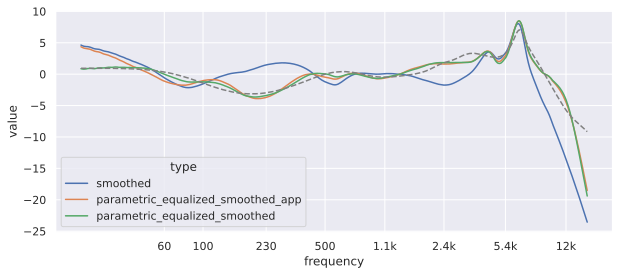

In [248]:
plt.figure(figsize=(10, 4))
sns.lineplot(
    data=df[
        df["type"].isin(
            [
                "smoothed",
                "parametric_equalized_smoothed_app",
                "parametric_equalized_smoothed",
            ]
        )
    ],
    x="frequency",
    y="value",
    hue="type",
    hue_order=[
        "smoothed",
        "parametric_equalized_smoothed_app",
        "parametric_equalized_smoothed",
    ],
)
# make the target line dashed
plt.plot(
    df[df["type"] == "target"]["frequency"],
    df[df["type"] == "target"]["value"],
    linestyle="dashed",
    color="grey",
)
freq_plot()
plt.show()

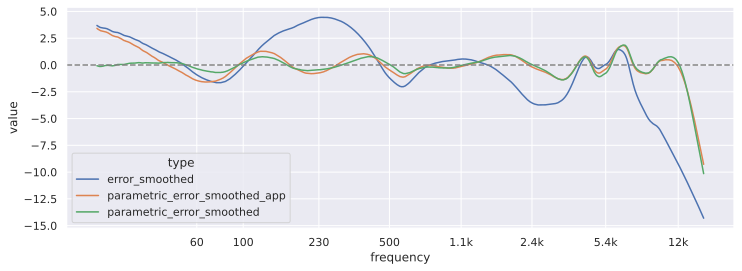

In [249]:
plt.figure(figsize=(12, 4))
sns.lineplot(
    data=df[
        df["type"].isin(
            [
                "error_smoothed",
                "parametric_error_smoothed_app",
                "parametric_error_smoothed",
            ]
        )
    ],
    x="frequency",
    y="value",
    hue="type",
    hue_order=[
        "error_smoothed",
        "parametric_error_smoothed_app",
        "parametric_error_smoothed",
    ],
)
freq_plot()
# Baseline
plt.axhline(0, color="gray", linestyle="--")
plt.show()

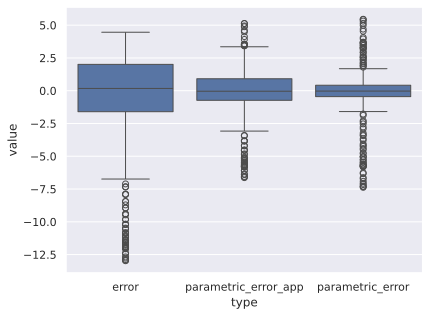

In [250]:
# boxplot
sns.boxplot(
    data=df[
        (df["frequency"] <= 16000)
        & (
            df["type"].isin(
                [
                    "error",
                    "parametric_error_app",
                    "parametric_error",
                ]
            )
        )
    ],
    x="type",
    y="value",
    order=[
        "error",
        "parametric_error_app",
        "parametric_error",
    ],
)
plt.show()

In [251]:
df[df["type"] == "parametric_error"]["value"].describe()

count    672.000000
mean      -0.160774
std        1.621502
min       -7.370000
25%       -0.452500
50%       -0.030000
75%        0.415000
max        5.450000
Name: value, dtype: float64

In [252]:

df[df["type"] == "parametric_error_app"]["value"].describe()

count    672.000000
mean      -0.009509
std        1.783552
min       -6.630000
25%       -0.730000
50%       -0.040000
75%        0.912500
max        5.130000
Name: value, dtype: float64

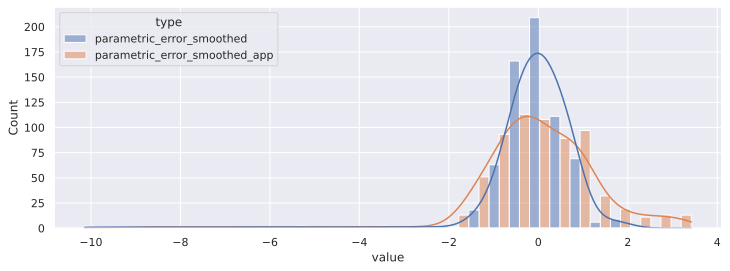

In [253]:
plt.figure(figsize=(12, 4))
sns.histplot(
    data=df[
        df["type"].isin(["parametric_error_smoothed", "parametric_error_smoothed_app"])
    ],
    x="value",
    hue="type",
    multiple="dodge",
    hue_order=["parametric_error_smoothed", "parametric_error_smoothed_app"],
    bins=30,
    kde=True,
)
plt.show()

In [254]:
df = df_orig.copy()
df["wavelet"] = df["parametric_error"]

df[["frequency", "wavelet"]].to_csv("../wavelet/wavelet_input.csv", index=False)